In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score

In [129]:
df=pd.read_csv(r"C:\Users\malon\OneDrive\Desktop\job_salary_prediction_dataset.csv")

In [130]:
df.head()


,job_title,experience_years,education_level,skills_count,industry,company_size,location,remote_work,certifications,salary
0,AI Engineer,10,Bachelor,2,Healthcare,Medium,India,Hybrid,2,109413
1,Data Analyst,5,Bachelor,17,Telecom,Small,Australia,No,0,93764
2,Frontend Developer,18,PhD,4,Media,Medium,Singapore,No,1,148123
3,Business Analyst,19,PhD,13,Retail,Medium,Canada,Yes,0,189123
4,Product Manager,15,Bachelor,7,Manufacturing,Large,Sweden,Yes,0,165069


In [131]:
df.columns

Index(['job_title', 'experience_years', 'education_level', 'skills_count',
       'industry', 'company_size', 'location', 'remote_work', 'certifications',
       'salary'],
      dtype='str')

In [132]:
df.shape
df.describe()
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 250000 entries, 0 to 249999
Data columns (total 10 columns):
 #   Column            Non-Null Count   Dtype
---  ------            --------------   -----
 0   job_title         250000 non-null  str  
 1   experience_years  250000 non-null  int64
 2   education_level   250000 non-null  str  
 3   skills_count      250000 non-null  int64
 4   industry          250000 non-null  str  
 5   company_size      250000 non-null  str  
 6   location          250000 non-null  str  
 7   remote_work       250000 non-null  str  
 8   certifications    250000 non-null  int64
 9   salary            250000 non-null  int64
dtypes: int64(4), str(6)
memory usage: 19.1 MB


Check Variable Types

In [133]:
categorical_vars = df.select_dtypes(include=['object', 'category']).columns
print("Categorical variables:")
print(list(categorical_vars))

Categorical variables:
['job_title', 'education_level', 'industry', 'company_size', 'location', 'remote_work']


C:\Users\malon\AppData\Local\Temp\ipykernel_14592\3471354323.py:1: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categorical_vars = df.select_dtypes(include=['object', 'category']).columns


In [134]:
numeric_vars = df.select_dtypes(include=['number']).columns
print("\nNumeric variables:")
print(list(numeric_vars))


Numeric variables:
['experience_years', 'skills_count', 'certifications', 'salary']


Check for Null Values

In [135]:
df.isnull().sum()


job_title           0
experience_years    0
education_level     0
skills_count        0
industry            0
company_size        0
location            0
remote_work         0
certifications      0
salary              0
dtype: int64

Encoding and Scaling Process

In [136]:
df_encoded = pd.get_dummies(df, columns=categorical_vars, drop_first=True)

In [137]:
from sklearn.preprocessing import StandardScaler

numeric_cols = df.select_dtypes(include=['number']).columns.tolist()

# Initialize the scaler
scaler = StandardScaler()

# Fit and transform
df_scaled = df.copy()
df_scaled[numeric_cols] = scaler.fit_transform(df[numeric_cols])

print("\nScaled data (first 5 rows):")
print(df_scaled[numeric_cols].head())

print("\nScaled data statistics (mean ≈ 0, std ≈ 1):")
print(df_scaled[numeric_cols].describe())


Scaled data (first 5 rows):
   experience_years  skills_count  certifications    salary
0         -0.000892     -1.459647       -0.288272 -0.970520
1         -0.825894      1.277940       -1.460281 -1.388854
2          1.319111     -1.094636       -0.874276  0.064289
3          1.484112      0.547917       -1.460281  1.160315
4          0.824110     -0.547118       -1.460281  0.517295

Scaled data statistics (mean ≈ 0, std ≈ 1):
       experience_years  skills_count  certifications        salary
count      2.500000e+05  2.500000e+05    2.500000e+05  2.500000e+05
mean       1.202807e-16  7.048584e-17   -5.911716e-17  2.683009e-16
std        1.000002e+00  1.000002e+00    1.000002e+00  1.000002e+00
min       -1.650897e+00 -1.642153e+00   -1.460281e+00 -3.043505e+00
25%       -8.258945e-01 -9.121298e-01   -8.742763e-01 -7.046666e-01
50%       -8.923223e-04  3.993227e-04   -2.882719e-01 -6.055090e-02
75%        8.241098e-01  9.129284e-01    8.837367e-01  6.355324e-01
max        1.649112e+0

# Model 1

In [138]:
X = df_scaled.drop( "salary", axis = 1)
y = df_scaled["salary"]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.2)



In [139]:
print(f"Training set size: {X_train.shape[0]}")
print(f"Test set size: {X_test.shape[0]}")
print(f"Features shape: {X_train.shape[1]}")
print(f"X_train dtypes:\n{X_train.dtypes.value_counts()}")

Training set size: 200000
Test set size: 50000
Features shape: 9
X_train dtypes:
str        6
float64    3
Name: count, dtype: int64


In [140]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score
cat_cols = X_train.select_dtypes(include=['object', 'category']).columns.tolist()

if len(cat_cols) > 0:
	# One-hot encode categorical columns in both train and test, then align columns
	X_train_enc = pd.get_dummies(X_train, columns=cat_cols, drop_first=True)
	X_test_enc = pd.get_dummies(X_test, columns=cat_cols, drop_first=True)
	# Align columns so both have same set (missing columns filled with 0)
	X_train_enc, X_test_enc = X_train_enc.align(X_test_enc, join='left', axis=1, fill_value=0)
else:
	X_train_enc = X_train.copy()
	X_test_enc = X_test.copy()

linear_reg = LinearRegression()
linear_reg.fit(X_train_enc, y_train)

# Make predictions
y_pred_train = linear_reg.predict(X_train_enc)
y_pred_test = linear_reg.predict(X_test_enc)

# Evaluate
mse = mean_squared_error(y_test, y_pred_test)
r2 = r2_score(y_test, y_pred_test)


print(f"Mean Squared Error: {mse:.4f}")	
print(f"R² Score: {r2:.4f}")

C:\Users\malon\AppData\Local\Temp\ipykernel_14592\4221340215.py:3: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  cat_cols = X_train.select_dtypes(include=['object', 'category']).columns.tolist()


Mean Squared Error: 0.0362
R² Score: 0.9637


In [141]:
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error
# Mean Absolute Error (MAE)
mae = mean_absolute_error(y_test, y_pred_test)
print(f"Mean Absolute Error (MAE): {mae:.4f}")

# Mean Squared Error (MSE)
mse = mean_squared_error(y_test, y_pred_test)
print(f"Mean Squared Error (MSE): {mse:.4f}")

# Root Mean Squared Error (RMSE)
rmse = np.sqrt(mse)
print(f"Root Mean Squared Error (RMSE): {rmse:.4f}")

# R-squared (R2)
r2 = r2_score(y_test, y_pred_test)
print(f"R-squared (R2): {r2:.4f}")

Mean Absolute Error (MAE): 0.1452
Mean Squared Error (MSE): 0.0362
Root Mean Squared Error (RMSE): 0.1902
R-squared (R2): 0.9637


Mean Absolute Percentage Error (MAPE): 1.8259

Residuals Statistics:
Mean of Residuals: 0.0003
Std of Residuals: 0.1902
Min Residual: -0.9847
Max Residual: 1.3099


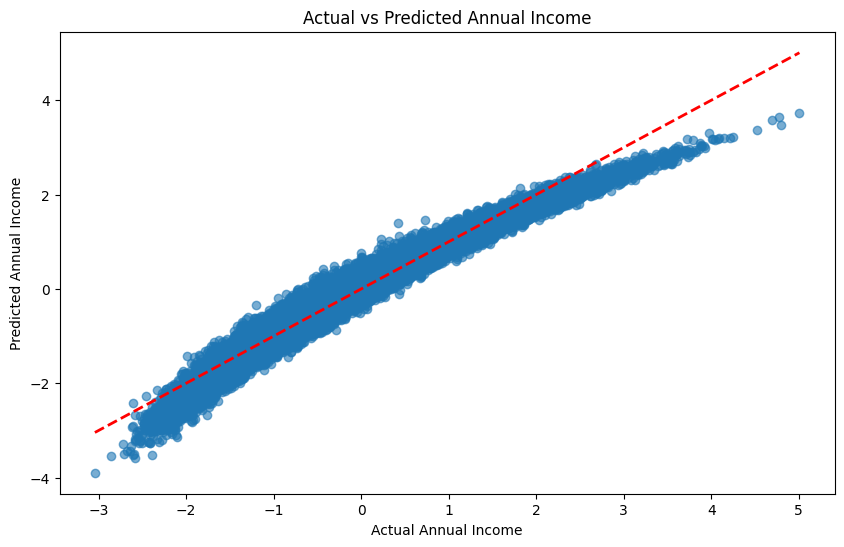

In [142]:
from sklearn.metrics import mean_absolute_percentage_error

# Additional Regression Metrics

# Mean Absolute Percentage Error (MAPE)
mape = mean_absolute_percentage_error(y_test, y_pred_test)
print(f"Mean Absolute Percentage Error (MAPE): {mape:.4f}")

# Residuals Analysis
residuals = y_test - y_pred_test
print(f"\nResiduals Statistics:")
print(f"Mean of Residuals: {residuals.mean():.4f}")
print(f"Std of Residuals: {residuals.std():.4f}")
print(f"Min Residual: {residuals.min():.4f}")
print(f"Max Residual: {residuals.max():.4f}")

# Plot Actual vs Predicted
plt.figure(figsize=(10, 6))
plt.scatter(y_test, y_pred_test, alpha=0.6)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2)
plt.xlabel("Actual Annual Income")
plt.ylabel("Predicted Annual Income")
plt.title("Actual vs Predicted Annual Income")
plt.show()

# Model 2, Dropped "Company_Size" 

In [143]:
df_2= df_scaled.copy()


In [144]:
df_2.drop(columns=['company_size'], inplace=True, errors='ignore')
X2 = df_2.drop( "salary", axis = 1)
y2 = df_2["salary"]

X2_train, X2_test, y2_train, y2_test = train_test_split(X2, y2, test_size = 0.2)


In [145]:
print(f"Training set size: {X2_train.shape[0]}")
print(f"Test set size: {X2_test.shape[0]}")
print(f"Features shape: {X2_train.shape[1]}")
print(f"X2_train dtypes:\n{X2_train.dtypes.value_counts()}")

Training set size: 200000
Test set size: 50000
Features shape: 8
X2_train dtypes:
str        5
float64    3
Name: count, dtype: int64


In [146]:
cat_cols = X2_train.select_dtypes(include=['object', 'category']).columns.tolist()

if len(cat_cols) > 0:
	# One-hot encode categorical columns in both train and test, then align columns
	X2_train_enc = pd.get_dummies(X2_train, columns=cat_cols, drop_first=True)
	X2_test_enc = pd.get_dummies(X2_test, columns=cat_cols, drop_first=True)
	# Align columns so both have same set (missing columns filled with 0)
	X2_train_enc, X2_test_enc = X2_train_enc.align(X2_test_enc, join='left', axis=1, fill_value=0)
else:
	X2_train_enc = X2_train.copy()
	X2_test_enc = X2_test.copy()

linear_reg = LinearRegression()
linear_reg.fit(X2_train_enc, y2_train)

# Make predictions
y2_pred_train = linear_reg.predict(X2_train_enc)
y2_pred_test = linear_reg.predict(X2_test_enc)

mse = mean_squared_error(y2_test, y2_pred_test)
r2 = r2_score(y2_test, y2_pred_test)


print(f"Mean Squared Error: {mse:.4f}")	
print(f"R² Score: {r2:.4f}")

C:\Users\malon\AppData\Local\Temp\ipykernel_14592\315163263.py:1: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  cat_cols = X2_train.select_dtypes(include=['object', 'category']).columns.tolist()


Mean Squared Error: 0.2024
R² Score: 0.7987


Mean Absolute Percentage Error (MAPE): 1.8259

Residuals Statistics:
Mean of Residuals: 0.0003
Std of Residuals: 0.1902
Min Residual: -0.9847
Max Residual: 1.3099


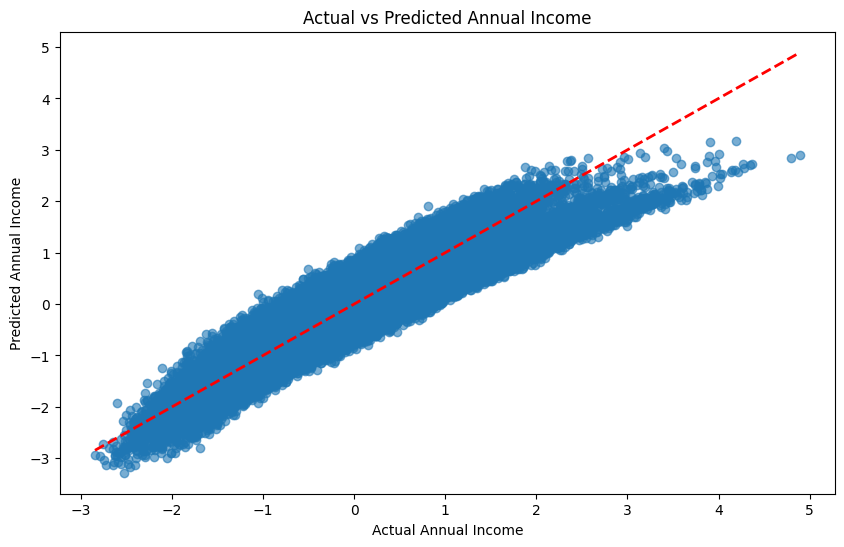

In [147]:
mape = mean_absolute_percentage_error(y_test, y_pred_test)
print(f"Mean Absolute Percentage Error (MAPE): {mape:.4f}")

# Residuals Analysis
residuals = y_test - y_pred_test
print(f"\nResiduals Statistics:")
print(f"Mean of Residuals: {residuals.mean():.4f}")
print(f"Std of Residuals: {residuals.std():.4f}")
print(f"Min Residual: {residuals.min():.4f}")
print(f"Max Residual: {residuals.max():.4f}")

# Plot Actual vs Predicted
plt.figure(figsize=(10, 6))
plt.scatter(y2_test, y2_pred_test, alpha=0.6)
plt.plot([y2_test.min(), y2_test.max()], [y2_test.min(), y2_test.max()], 'r--', lw=2)
plt.xlabel("Actual Annual Income")
plt.ylabel("Predicted Annual Income")
plt.title("Actual vs Predicted Annual Income")
plt.show()

# Model 3, Dropped "Remote_Work" 

In [148]:
df_3= df_scaled.copy()


In [149]:
df_3.drop(columns=['remote_work'], inplace=True, errors='ignore') 
X3 = df_3.drop( "salary", axis = 1)
y3 = df_3["salary"]

X3_train, X3_test, y3_train, y3_test = train_test_split(X3, y3, test_size = 0.2)


In [150]:
print(f"Training set size: {X3_train.shape[0]}")
print(f"Test set size: {X3_test.shape[0]}")
print(f"Features shape: {X3_train.shape[1]}")
print(f"X3_train dtypes:\n{X3_train.dtypes.value_counts()}")

Training set size: 200000
Test set size: 50000
Features shape: 8
X3_train dtypes:
str        5
float64    3
Name: count, dtype: int64


In [151]:
cat_cols = X3_train.select_dtypes(include=['object', 'category']).columns.tolist()

if len(cat_cols) > 0:
	# One-hot encode categorical columns in both train and test, then align columns
	X3_train_enc = pd.get_dummies(X3_train, columns=cat_cols, drop_first=True)
	X3_test_enc = pd.get_dummies(X3_test, columns=cat_cols, drop_first=True)
	# Align columns so both have same set (missing columns filled with 0)
	X3_train_enc, X3_test_enc = X3_train_enc.align(X3_test_enc, join='left', axis=1, fill_value=0)
else:
	X3_train_enc = X3_train.copy()
	X3_test_enc = X3_test.copy()

linear_reg = LinearRegression()
linear_reg.fit(X3_train_enc, y3_train)

# Make predictions
y3_pred_train = linear_reg.predict(X3_train_enc)
y3_pred_test = linear_reg.predict(X3_test_enc)

mse = mean_squared_error(y3_test, y3_pred_test)
r2 = r2_score(y3_test, y3_pred_test)


print(f"Mean Squared Error: {mse:.4f}")	
print(f"R² Score: {r2:.4f}")

C:\Users\malon\AppData\Local\Temp\ipykernel_14592\2563594204.py:1: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  cat_cols = X3_train.select_dtypes(include=['object', 'category']).columns.tolist()


Mean Squared Error: 0.0406
R² Score: 0.9597


Mean Absolute Percentage Error (MAPE): 1.8259

Residuals Statistics:
Mean of Residuals: 0.0003
Std of Residuals: 0.1902
Min Residual: -0.9847
Max Residual: 1.3099


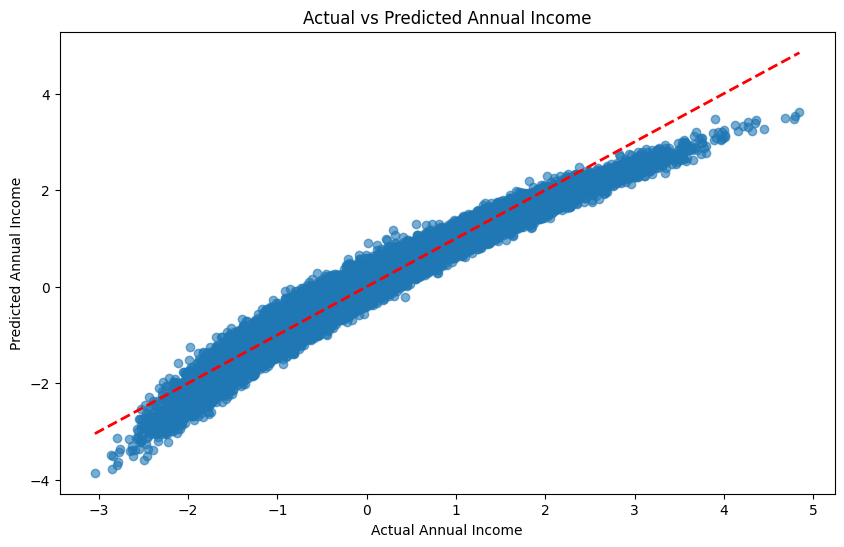

In [152]:
mape = mean_absolute_percentage_error(y_test, y_pred_test)
print(f"Mean Absolute Percentage Error (MAPE): {mape:.4f}")

# Residuals Analysis
residuals = y_test - y_pred_test
print(f"\nResiduals Statistics:")
print(f"Mean of Residuals: {residuals.mean():.4f}")
print(f"Std of Residuals: {residuals.std():.4f}")
print(f"Min Residual: {residuals.min():.4f}")
print(f"Max Residual: {residuals.max():.4f}")

# Plot Actual vs Predicted
plt.figure(figsize=(10, 6))
plt.scatter(y3_test, y3_pred_test, alpha=0.6)
plt.plot([y3_test.min(), y3_test.max()], [y3_test.min(), y3_test.max()], 'r--', lw=2)
plt.xlabel("Actual Annual Income")
plt.ylabel("Predicted Annual Income")
plt.title("Actual vs Predicted Annual Income")
plt.show()

# Model 4, Dropped Experience

In [153]:
df_4 = df_scaled.copy()

In [154]:
df_4.drop(columns=['experience_years'], inplace=True, errors='ignore') 
X4 = df_4.drop( "salary", axis = 1)
y4 = df_4["salary"]

X4_train, X4_test, y4_train, y4_test = train_test_split(X4, y4, test_size = 0.2)


In [155]:
print(f"Training set size: {X4_train.shape[0]}")
print(f"Test set size: {X4_test.shape[0]}")
print(f"Features shape: {X4_train.shape[1]}")
print(f"X4_train dtypes:\n{X4_train.dtypes.value_counts()}")

Training set size: 200000
Test set size: 50000
Features shape: 8
X4_train dtypes:
str        6
float64    2
Name: count, dtype: int64


In [156]:
cat_cols = X4_train.select_dtypes(include=['object', 'category']).columns.tolist()

if len(cat_cols) > 0:
	# One-hot encode categorical columns in both train and test, then align columns
	X4_train_enc = pd.get_dummies(X4_train, columns=cat_cols, drop_first=True)
	X4_test_enc = pd.get_dummies(X4_test, columns=cat_cols, drop_first=True)
	# Align columns so both have same set (missing columns filled with 0)
	X4_train_enc, X4_test_enc = X4_train_enc.align(X4_test_enc, join='left', axis=1, fill_value=0)
else:
	X4_train_enc = X4_train.copy()
	X4_test_enc = X4_test.copy()

linear_reg = LinearRegression()
linear_reg.fit(X4_train_enc, y4_train)

# Make predictions
y4_pred_train = linear_reg.predict(X4_train_enc)
y4_pred_test = linear_reg.predict(X4_test_enc)

mse = mean_squared_error(y4_test, y4_pred_test)
r2 = r2_score(y4_test, y4_pred_test)


print(f"Mean Squared Error: {mse:.4f}")	
print(f"R² Score: {r2:.4f}")

C:\Users\malon\AppData\Local\Temp\ipykernel_14592\4153001412.py:1: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  cat_cols = X4_train.select_dtypes(include=['object', 'category']).columns.tolist()


Mean Squared Error: 0.2262
R² Score: 0.7721


Mean Absolute Percentage Error (MAPE): 1.8259

Residuals Statistics:
Mean of Residuals: 0.0003
Std of Residuals: 0.1902
Min Residual: -0.9847
Max Residual: 1.3099


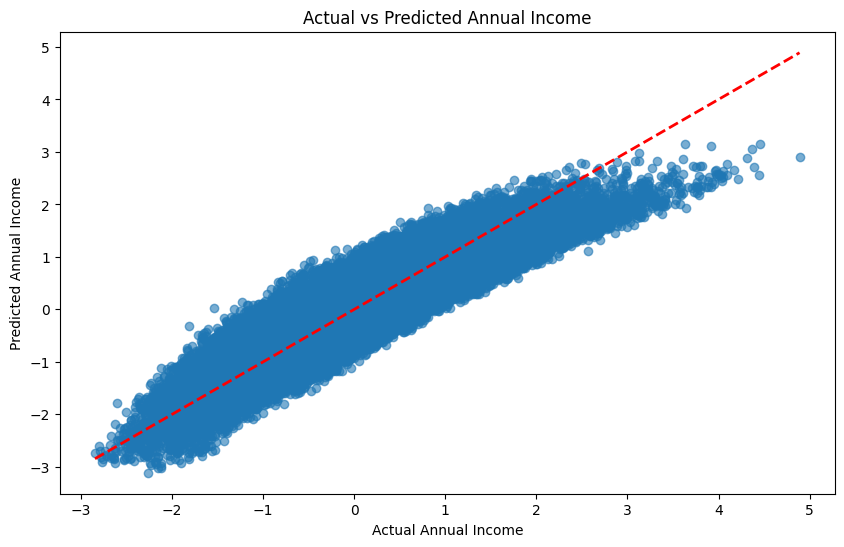

In [157]:
mape = mean_absolute_percentage_error(y_test, y_pred_test)
print(f"Mean Absolute Percentage Error (MAPE): {mape:.4f}")

# Residuals Analysis
residuals = y_test - y_pred_test
print(f"\nResiduals Statistics:")
print(f"Mean of Residuals: {residuals.mean():.4f}")
print(f"Std of Residuals: {residuals.std():.4f}")
print(f"Min Residual: {residuals.min():.4f}")
print(f"Max Residual: {residuals.max():.4f}")

# Plot Actual vs Predicted
plt.figure(figsize=(10, 6))
plt.scatter(y4_test, y4_pred_test, alpha=0.6)
plt.plot([y4_test.min(), y4_test.max()], [y4_test.min(), y4_test.max()], 'r--', lw=2)
plt.xlabel("Actual Annual Income")
plt.ylabel("Predicted Annual Income")
plt.title("Actual vs Predicted Annual Income")
plt.show()